In [1]:
"""
Soft-voting ensemble of the top 3 models (SVM-Linear, Logistic Regression,
Ridge Classifier): average their predicted PD probabilities and apply a
fixed decision threshold of 0.35 (matches report section 4.4).

Loads best_of from the saved pickle (from 03_model_comparison.ipynb) rather
than depending on that notebook having run in the same session.
"""

import os
import numpy as np
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import sys
sys.path.append("..")  # so config.py (in the repo root) is importable from notebooks/
from config import RANDOM_STATE, FEATURE_MATRIX_PATH, PARTICIPANTS_TSV, ALL_RESULTS_PKL, MODELS_DIR, FIGURES_DIR

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

SOFT_VOTE_THRESHOLD = 0.35
TOP3_NAMES = ["SVM_Linear", "LogisticRegression", "RidgeClassifier"]


def load_data():
    feat_df = pd.read_csv(FEATURE_MATRIX_PATH)
    subject_list = feat_df["Subject"].tolist()
    X = feat_df.drop(columns=["Subject"]).values

    participants_df = pd.read_csv(PARTICIPANTS_TSV, sep="\t")
    label_map = {"Control": 0, "PD-NC": 1, "PD-MCI": 1}
    y = np.array([
        label_map[participants_df.loc[participants_df["participant_id"] == s, "group"].values[0]]
        for s in subject_list
    ])
    return X, y


# load already-fitted models from disk (no re-running the 10-model comparison)
results = joblib.load(ALL_RESULTS_PKL)
best_of = results["best_of"]
y_test = results["y_test"]

# reload X, y and recreate the exact same train/test split used to build best_of
X, y = load_data()
X_train, X_test, y_train, y_test_check = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
assert np.array_equal(y_test_check, y_test), "Split doesn't match best_of's y_test"

top3_models = {name: best_of[name]["_model"] for name in TOP3_NAMES}

print(f"Loaded {len(best_of)} models from {ALL_RESULTS_PKL}")
print(f"Soft-voting threshold: {SOFT_VOTE_THRESHOLD} (fixed)")


Loaded 10 models from C:/Users/XPRISTO/Desktop/PD_PROJECT\models\all_results.pkl
Soft-voting threshold: 0.35 (fixed)


In [2]:
def soft_vote_probs(models_dict, X_data):
    probs = [models_dict[name].predict_proba(X_data)[:, 1] for name in TOP3_NAMES]
    return np.mean(probs, axis=0)


# fit each model on the full training set, then soft-vote on the test set
for name in TOP3_NAMES:
    top3_models[name].fit(X_train, y_train)

avg_prob_test = soft_vote_probs(top3_models, X_test)
soft_vote_pred = (avg_prob_test >= SOFT_VOTE_THRESHOLD).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, soft_vote_pred, labels=[0, 1]).ravel()
print(f"Confusion: TN={tn} FP={fp} FN={fn} TP={tp}\n")
print(classification_report(y_test, soft_vote_pred, target_names=["HC", "PD"], zero_division=0))


Confusion: TN=2 FP=2 FN=0 TP=7

              precision    recall  f1-score   support

          HC       1.00      0.50      0.67         4
          PD       0.78      1.00      0.88         7

    accuracy                           0.82        11
   macro avg       0.89      0.75      0.77        11
weighted avg       0.86      0.82      0.80        11



In [3]:
# per-subject breakdown
subject_ids = [f"S{i+1:02d}" for i in range(len(y_test))]
label_names = {0: "HC", 1: "PD"}

table = pd.DataFrame({
    "Subject": subject_ids,
    "True_Label": [label_names[v] for v in y_test],
    "SoftVote_pred": [label_names[v] for v in soft_vote_pred],
    "Avg_Prob_PD": np.round(avg_prob_test, 3),
})
table["Result"] = np.where(soft_vote_pred == y_test, "Correct", "WRONG")
table


,Subject,True_Label,SoftVote_pred,Avg_Prob_PD,Result
0,S01,HC,PD,0.481,WRONG
1,S02,HC,HC,0.112,Correct
2,S03,PD,PD,0.843,Correct
3,S04,PD,PD,0.745,Correct
4,S05,PD,PD,0.595,Correct
5,S06,HC,HC,0.325,Correct
6,S07,PD,PD,0.460,Correct
7,S08,PD,PD,0.914,Correct
8,S09,PD,PD,0.957,Correct
9,S10,HC,PD,0.525,WRONG


In [4]:
"""
===========================================================================
SUBJECT-LEVEL PREDICTIONS \u2014 TOP 3 MODELS + SOFT VOTING
===========================================================================
"""
top3_thresholds = {name: best_of[name]["threshold"] for name in TOP3_NAMES}

# refit all 3 models on the full training set and get test predictions
n_subjects = len(y_test)
subject_labels = [f"S{i+1:02d}" for i in range(n_subjects)]
preds = {}   # binary predictions per model
probs = {}   # probabilities per model
for name in TOP3_NAMES:
    model = best_of[name]["_model"]
    model.fit(X_train, y_train)
    prob = model.predict_proba(X_test)[:, 1]
    probs[name] = prob
    preds[name] = (prob >= top3_thresholds[name]).astype(int)

# soft voting
avg_prob = np.stack([probs[n] for n in TOP3_NAMES], axis=1).mean(axis=1)
preds["SoftVoting"] = (avg_prob >= SOFT_VOTE_THRESHOLD).astype(int)
probs["SoftVoting"] = avg_prob
all_model_names = TOP3_NAMES + ["SoftVoting"]

# build display
label_map = {0: "HC", 1: "PD"}
col_w = 8
name_w = 22
header_cols = "".join(f"{s:<{col_w}}" for s in subject_labels)
sep = "-" * (name_w + col_w * n_subjects)
print("\n" + "=" * (name_w + col_w * n_subjects))
print("SUBJECT-LEVEL PREDICTIONS \u2014 TOP 3 MODELS + SOFT VOTING")
print("=" * (name_w + col_w * n_subjects))
print(f"{'Model':<{name_w}}{header_cols}")
print(sep)

# real labels
real_row = "".join(f"{label_map[y_test[i]]:<{col_w}}" for i in range(n_subjects))
print(f"{'Real Label':<{name_w}}{real_row}")
print(sep)

# per-model predictions
for name in all_model_names:
    row = ""
    for i in range(n_subjects):
        pred_label = label_map[preds[name][i]]
        true_label = label_map[y_test[i]]
        mark = "\u2713" if pred_label == true_label else "\u2717"
        cell = f"{pred_label}{mark}"
        row += f"{cell:<{col_w}}"
    display_name = name.replace("SoftVoting", "SoftVote")
    print(f"  {display_name:<{name_w-2}}{row}")
print(sep)

# votes for PD (from the 3 individual models only)
votes_pd = np.array([
    sum(preds[name][i] == 1 for name in TOP3_NAMES)
    for i in range(n_subjects)
])
agree_pct = (votes_pd / len(TOP3_NAMES) * 100).astype(int)
votes_row = "".join(f"{v:<{col_w}}" for v in votes_pd)
agree_row = "".join(f"{p}%{'':<{col_w-len(str(p))-1}}" for p in agree_pct)
print(f"{'Votes for PD':<{name_w}}{votes_row}")
print(f"{'Agreement %':<{name_w}}{agree_row}")
print(sep)

# soft vote final prediction
sv_row = "".join(
    f"{label_map[preds['SoftVoting'][i]]:<{col_w}}"
    for i in range(n_subjects)
)
print(f"{'SoftVote Final':<{name_w}}{sv_row}")

# probability row
prob_row = "".join(f"{avg_prob[i]:.2f}{'':>{col_w-4}}" for i in range(n_subjects))
print(f"{'Avg Probability':<{name_w}}{prob_row}")
print("=" * (name_w + col_w * n_subjects))

# per-subject summary
print(f"\n{'Subject':<10} {'True':>6} {'SoftVote':>10} {'Avg Prob':>10} "
      f"{'Votes PD':>10} {'Agree%':>8} {'Result':>8}")
print("-" * 65)
for i in range(n_subjects):
    true = label_map[y_test[i]]
    sv_pred = label_map[preds["SoftVoting"][i]]
    mark = "\u2713" if sv_pred == true else "\u2717"
    print(f"  {subject_labels[i]:<8} {true:>6} {sv_pred+mark:>10} "
          f"{avg_prob[i]:>10.3f} {votes_pd[i]:>10} {agree_pct[i]:>7}%"
          f"{'  correct' if mark=='\u2713' else '  WRONG':>9}")



SUBJECT-LEVEL PREDICTIONS — TOP 3 MODELS + SOFT VOTING
Model                 S01     S02     S03     S04     S05     S06     S07     S08     S09     S10     S11     
--------------------------------------------------------------------------------------------------------------
Real Label            HC      HC      PD      PD      PD      HC      PD      PD      PD      HC      PD      
--------------------------------------------------------------------------------------------------------------
  SVM_Linear          PD✗     HC✓     PD✓     PD✓     PD✓     HC✓     PD✓     PD✓     PD✓     PD✗     PD✓     
  LogisticRegression  HC✓     HC✓     PD✓     PD✓     PD✓     HC✓     PD✓     PD✓     PD✓     PD✗     HC✗     
  RidgeClassifier     HC✓     HC✓     PD✓     PD✓     PD✓     HC✓     PD✓     PD✓     PD✓     PD✗     HC✗     
  SoftVote            PD✗     HC✓     PD✓     PD✓     PD✓     HC✓     PD✓     PD✓     PD✓     PD✗     PD✓     
--------------------------------------------------------

C:\Users\XPRISTO\AppData\Local\Temp\ipykernel_576\2992968695.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.02, 1, 0.96])


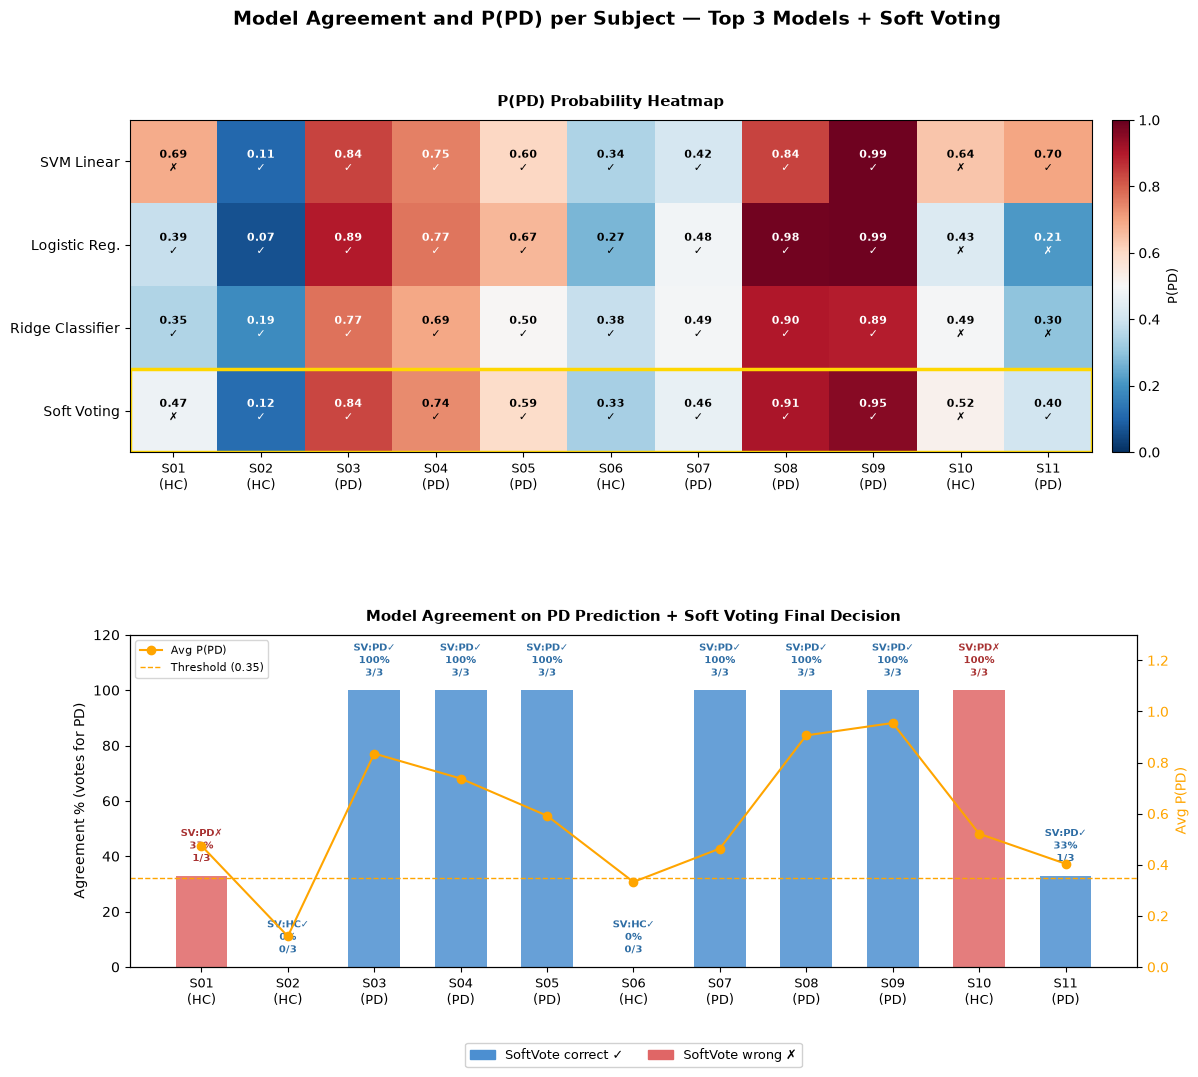

Saved: C:/Users/XPRISTO/Desktop/PD_PROJECT\figures\model_agreement_probability.png


In [7]:
"""
MODEL AGREEMENT AND P(PD) PER SUBJECT — HEATMAP + BAR/LINE CHART

Two-panel figure: top panel is a P(PD) heatmap for each of the top-3 models
plus Soft Voting (with checkmarks showing correct/incorrect vs. true label);
bottom panel is the agreement-% bar chart (blue if Soft Voting got that
subject right, red if wrong) with the average P(PD) line overlaid.
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import TwoSlopeNorm

heatmap_models = TOP3_NAMES + ["SoftVoting"]
heatmap_row_labels = ["SVM Linear", "Logistic Reg.", "Ridge Classifier", "Soft Voting"]

# true label per subject, for column headers and correctness marks
true_label_str = [label_map[y_test[i]] for i in range(n_subjects)]
col_headers = [f"{subject_labels[i]}\n({true_label_str[i]})" for i in range(n_subjects)]

fig = plt.figure(figsize=(13, 11))
gs = fig.add_gridspec(2, 1, height_ratios=[1, 1], hspace=0.55)

fig.suptitle("Model Agreement and P(PD) per Subject \u2014 Top 3 Models + Soft Voting",
             fontsize=14, fontweight="bold", y=0.98)

# top panel: P(PD) heatmap
ax0 = fig.add_subplot(gs[0])
heat_data = np.array([probs[name] for name in heatmap_models])  # shape (4, n_subjects)

norm = TwoSlopeNorm(vmin=0, vcenter=0.5, vmax=1)
im = ax0.imshow(heat_data, cmap="RdBu_r", norm=norm, aspect="auto")

ax0.set_xticks(range(n_subjects))
ax0.set_xticklabels(col_headers, fontsize=9)
ax0.set_yticks(range(len(heatmap_models)))
ax0.set_yticklabels(heatmap_row_labels, fontsize=10)
ax0.set_title("P(PD) Probability Heatmap", fontsize=11, fontweight="bold", pad=10)

for r, name in enumerate(heatmap_models):
    for c in range(n_subjects):
        p = heat_data[r, c]
        pred_label = "PD" if p >= (top3_thresholds[name] if name in top3_thresholds else SOFT_VOTE_THRESHOLD) else "HC"
        mark = "\u2713" if pred_label == true_label_str[c] else "\u2717"
        text_color = "white" if (p > 0.75 or p < 0.25) else "black"
        ax0.text(c, r, f"{p:.2f}\n{mark}", ha="center", va="center",
                  fontsize=8, color=text_color, fontweight="bold")

# highlight the Soft Voting row with a yellow border
n_rows = len(heatmap_models)
rect = plt.Rectangle((-0.5, n_rows - 1 - 0.5), n_subjects, 1,
                      fill=False, edgecolor="gold", linewidth=2.5)
ax0.add_patch(rect)

cbar = fig.colorbar(im, ax=ax0, fraction=0.025, pad=0.02)
cbar.set_label("P(PD)", fontsize=9)

# bottom panel: agreement % bars + avg P(PD) line 
ax1 = fig.add_subplot(gs[1])

bar_colors = ["#4C8FD1" if preds["SoftVoting"][i] == y_test[i] else "#E06666"
              for i in range(n_subjects)]
bars = ax1.bar(range(n_subjects), agree_pct, color=bar_colors, alpha=0.85, width=0.6)

for i, bar in enumerate(bars):
    sv_pred = label_map[preds["SoftVoting"][i]]
    sv_mark = "\u2713" if preds["SoftVoting"][i] == y_test[i] else "\u2717"
    label = f"SV:{sv_pred}{sv_mark}\n{agree_pct[i]}%\n{votes_pd[i]}/3"
    color = "#2E6DA4" if sv_mark == "\u2713" else "#A83232"
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 4,
              label, ha="center", va="bottom", fontsize=7.5, color=color, fontweight="bold")

ax1.set_ylim(0, 120)
ax1.set_ylabel("Agreement % (votes for PD)")
ax1.set_xticks(range(n_subjects))
ax1.set_xticklabels(col_headers, fontsize=9)
ax1.set_title("Model Agreement on PD Prediction + Soft Voting Final Decision",
              fontsize=11, fontweight="bold", pad=10)

ax2 = ax1.twinx()
ax2.plot(range(n_subjects), avg_prob, color="orange", marker="o", linewidth=1.5, label="Avg P(PD)")
ax2.axhline(SOFT_VOTE_THRESHOLD, color="orange", linestyle="--", linewidth=1,
            label=f"Threshold ({SOFT_VOTE_THRESHOLD})")
ax2.set_ylabel("Avg P(PD)", color="orange")
ax2.set_ylim(0, 1.3)
ax2.tick_params(axis="y", labelcolor="orange")
ax2.legend(loc="upper left", fontsize=8)

legend_handles = [mpatches.Patch(color="#4C8FD1", label="SoftVote correct \u2713"),
                   mpatches.Patch(color="#E06666", label="SoftVote wrong \u2717")]
ax1.legend(handles=legend_handles, loc="lower center", bbox_to_anchor=(0.5, -0.32),
           ncol=2, fontsize=9, framealpha=0.9)

plt.tight_layout(rect=[0, 0.02, 1, 0.96])

fig_path = os.path.join(FIGURES_DIR, "model_agreement_probability.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")


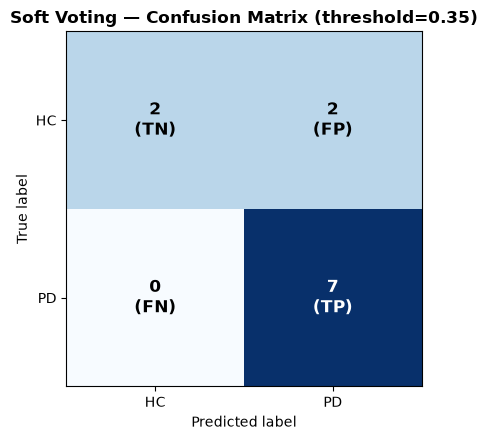

Saved: soft_voting_confusion_matrix.png


In [5]:
# confusion matrix plot
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, soft_vote_pred, labels=[0, 1])

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["HC", "PD"]); ax.set_yticklabels(["HC", "PD"])
ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")

labels_grid = np.array([["TN", "FP"], ["FN", "TP"]])
thresh = cm.max() / 2
for row in range(2):
    for col in range(2):
        color = "white" if cm[row, col] > thresh else "black"
        ax.text(col, row, f"{cm[row, col]}\n({labels_grid[row, col]})",
                ha="center", va="center", fontsize=12, fontweight="bold", color=color)

ax.set_title(f"Soft Voting \u2014 Confusion Matrix (threshold={SOFT_VOTE_THRESHOLD})", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "soft_voting_confusion_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: soft_voting_confusion_matrix.png")


In [6]:
# save soft-voting results alongside the individual model results
soft_voting_results = {
    "threshold": SOFT_VOTE_THRESHOLD,
    "y_test": y_test,
    "y_pred": soft_vote_pred,
    "y_prob": avg_prob_test,
    "table": table,
}
soft_voting_path = os.path.join(MODELS_DIR, "soft_voting_results.pkl")
joblib.dump(soft_voting_results, soft_voting_path)
print(f"Saved: {soft_voting_path}")


Saved: C:/Users/XPRISTO/Desktop/PD_PROJECT\models\soft_voting_results.pkl
